In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive has been mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive has been mounted successfully.


In [ ]:
import os
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'

# Delete ONLY extracted folders (keep ZIPs)
!rm -rf "{BASE_DIR}/Evening_"*"_aug_img"

print("🧹 Cleared old folders")

# Extract ALL 4 ZIPs fresh with OVERWRITE flag
zip_files = [
    'Evening_Fire_Incident_aug_img.zip',
    'Evening_Forest_Condition_aug_img.zip',
    'Pre-_Evening_Fire_Incident_aug_img.zip',
    'Pre-_Evening_Forest_Condition_aug_img.zip'
]

for zip_file in zip_files:
    zip_path = f"{BASE_DIR}{zip_file}"
    print(f"🔄 Extracting {zip_file}...")
    !unzip -o "{zip_path}" -d "{BASE_DIR}"
    print(f"✅ {zip_file} done")

print("\n🎉 ALL 4 CLASSES EXTRACTED!")


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3506.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3507.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3508.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3509.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_351.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3510.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3511.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3512.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_aug_img/1_3513.png  
  inflating: /content/drive/MyDrive/MHCNNFD_Data/Pre-_Evening_Fire_Incident_a

In [ ]:
for folder in ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
              'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']:
    path = f"{BASE_DIR}{folder}"
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"{folder}: {count} files")


Evening_Fire_Incident_aug_img: 3890 files
Evening_Forest_Condition_aug_img: 3890 files
Pre-_Evening_Fire_Incident_aug_img: 3890 files
Pre-_Evening_Forest_Condition_aug_img: 3890 files


In [ ]:
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# DataFrame (scans all 15,560 images)
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'
all_image_paths = []
all_labels = []

class_names_long = ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
                   'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
class_names_short = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                    'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

for long_name, short_name in zip(class_names_long, class_names_short):
    class_dir = os.path.join(BASE_DIR, long_name)
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        paths = glob.glob(os.path.join(class_dir, ext))
        all_image_paths.extend(paths)
        all_labels.extend([short_name] * len(paths))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'])

print(f"✅ Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")


✅ Train: 12448, Val: 1556, Test: 1556


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    df_train, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    df_val, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)


Found 12448 validated image filenames belonging to 4 classes.
Found 1556 validated image filenames belonging to 4 classes.


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(input_shape=(256, 256, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = build_model()
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

history = model.fit(train_gen, epochs=40, validation_data=val_gen,
                   callbacks=[tf.keras.callbacks.LearningRateScheduler(lr_scheduler)])


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
389/389 ━━━━━━━━━━━━━━━━━━━━ 283s 657ms/step - accuracy: 0.9471 - loss: 0.1578 - val_accuracy: 0.6902 - val_loss: 3.7267 - learning_rate: 0.0010
Epoch 2/40
389/389 ━━━━━━━━━━━━━━━━━━━━ 221s 568ms/step - accuracy: 0.9895 - loss: 0.0357 - val_accuracy: 0.7911 - val_loss: 1.0129 - learning_rate: 0.0010
Epoch 3/40
389/389 ━━━━━━━━━━━━━━━━━━━━ 223s 572ms/step - accuracy: 0.9930 - loss: 0.0201 - val_accuracy: 0.5051 - val_loss: 4.8135 - learning_rate: 0.0010
Epoch 4/40
389/389 ━━━━━━━━━━━━━━━━━━━━ 224s 576ms/step - accuracy: 0.9949 - loss: 0.0160 - val_accuracy: 0.6979 - val_loss: 3.0474 - learning_rate: 0.0010
Epoch 5/40
389/389 ━━━━━━━━━━━━━━━━━━━━ 221s 567ms/step - accuracy: 0.9974 - loss: 0.0084 - val_accuracy: 0.7731 - val_loss: 0.9319 - learning_rate: 0.0010
Epoch 6/40
389/389 ━━━━━━━━━━━━━━━━━━━━ 222s 570ms/step - accuracy: 0.9954 - loss: 0.0145 - val_accuracy: 0.8702 - val_loss: 0.4943 - learning_rate: 0.0010
Epoch 7/40
389/389 ━━━━━━━━━━━━━━━━━━━━ 261s 568ms/step - accura

Found 1556 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 FINAL TEST: 1.0000 (100.00%)
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 407ms/step

📊 CLASSIFICATION REPORT:
                               precision    recall  f1-score   support

        Evening_Fire_Incident       1.00      1.00      1.00       389
     Evening_Forest_Condition       1.00      1.00      1.00       389
   Pre-_Evening_Fire_Incident       1.00      1.00      1.00       389
Pre-_Evening_Forest_Condition       1.00      1.00      1.00       389

                     accuracy                           1.00      1556
                    macro avg       1.00      1.00      1.00      1556
                 weighted avg       1.00      1.00      1.00      1556



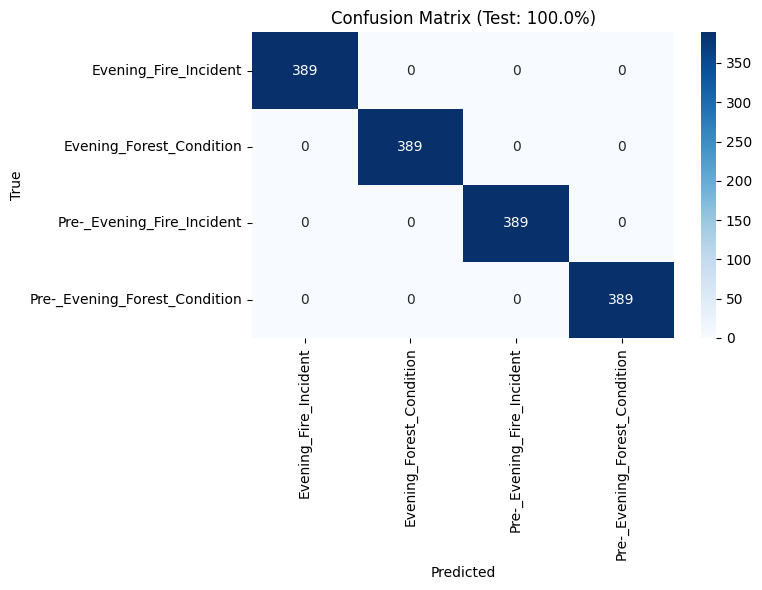

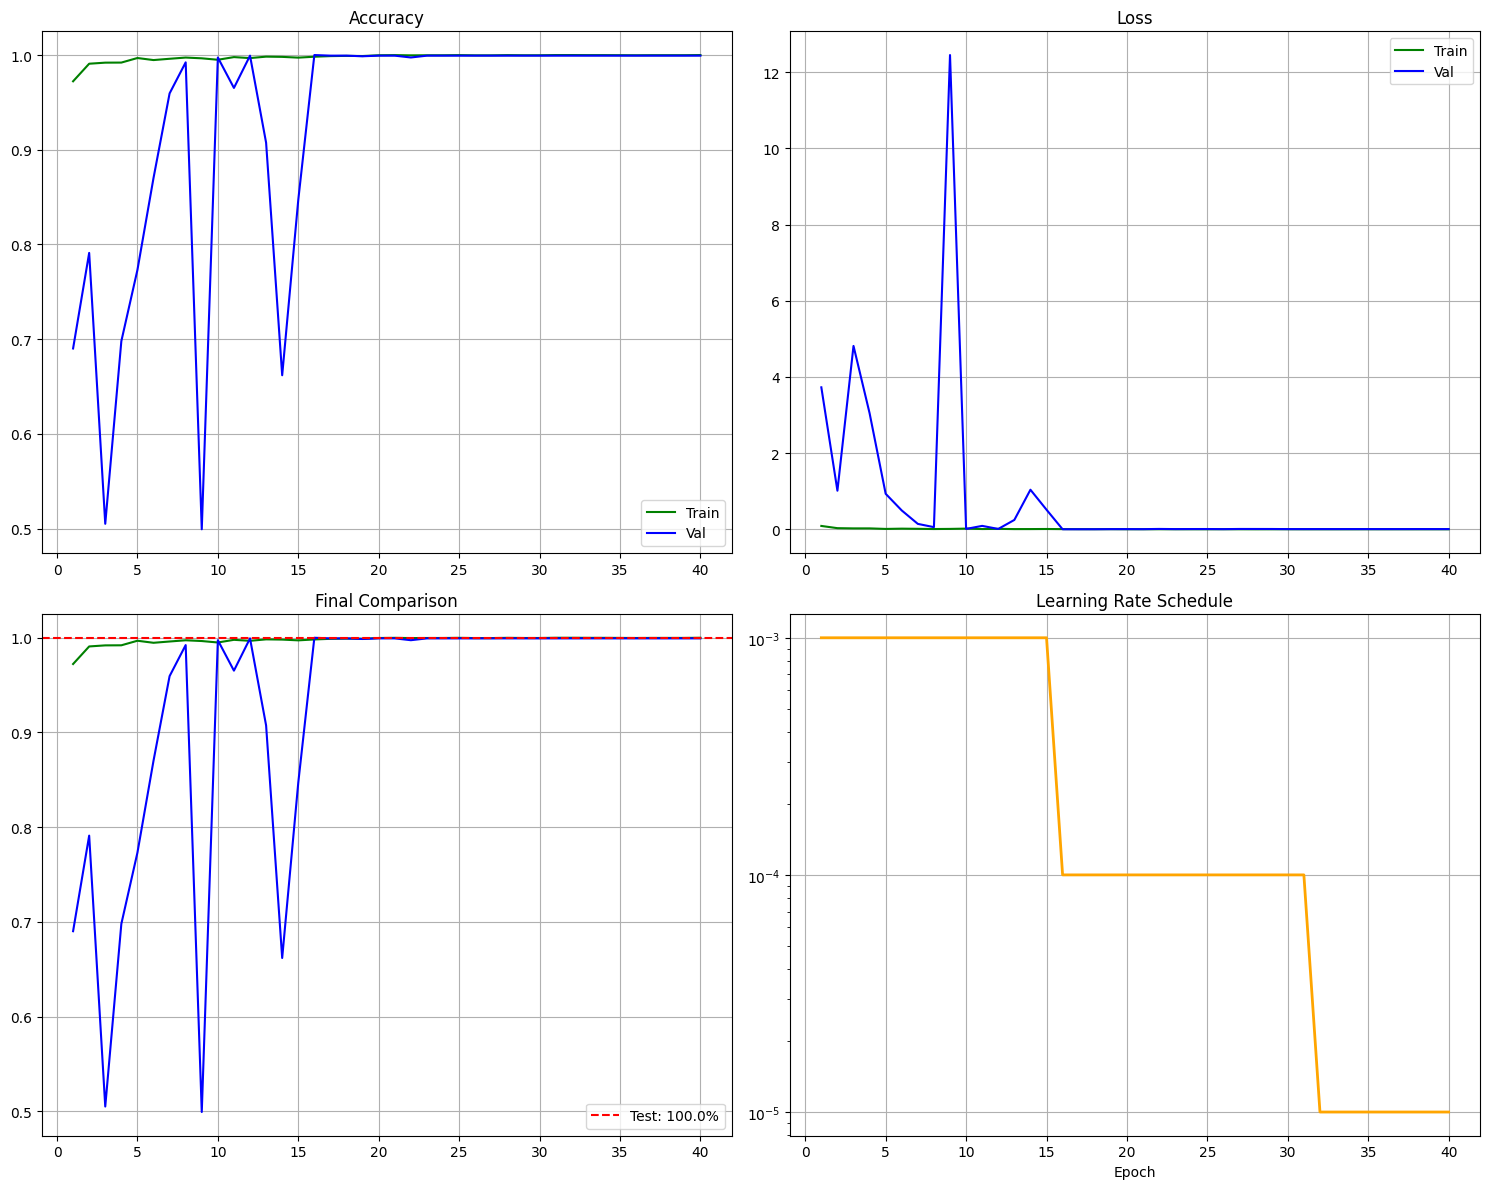


 MODEL PARAMS: 746,628
SAVED: Model, History, CM.png, Curves.png → /content/drive/MyDrive/
UAVs-FFDB SOTA: 1.0000


In [ ]:
# COMPLETE ANALYSIS
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns
import pickle

# 1. TEST EVALUATION
test_gen = datagen.flow_from_dataframe(
    df_test, x_col='path', y_col='label', target_size=(256,256),
    batch_size=32, class_mode='categorical', shuffle=False
)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f" FINAL TEST: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 2. PREDICTIONS + FULL METRICS
y_pred = model.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred_classes,
                          target_names=class_names_short))

# 3. CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_short, yticklabels=class_names_short)
plt.title(f'Confusion Matrix (Test: {test_acc:.1%})')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CM_UAVsFFDB_Model2.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. TRAINING CURVES (4 plots)
fig, axes = plt.subplots(2, 2, figsize=(15,12))
epochs = range(1, len(history.history['accuracy'])+1)

axes[0,0].plot(epochs, history.history['accuracy'], 'g-', label='Train')
axes[0,0].plot(epochs, history.history['val_accuracy'], 'b-', label='Val')
axes[0,0].set_title('Accuracy'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(epochs, history.history['loss'], 'g-', label='Train')
axes[0,1].plot(epochs, history.history['val_loss'], 'b-', label='Val')
axes[0,1].set_title('Loss'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(epochs, history.history['accuracy'], 'g-')
axes[1,0].plot(epochs, history.history['val_accuracy'], 'b-')
axes[1,0].axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.1%}')
axes[1,0].set_title('Final Comparison'); axes[1,0].legend(); axes[1,0].grid(True)

# LR schedule visualization
lr_values = [lr_scheduler(e-1) for e in epochs]
axes[1,1].plot(epochs, lr_values, 'orange', linewidth=2)
axes[1,1].set_title('Learning Rate Schedule'); axes[1,1].set_yscale('log')
axes[1,1].grid(True); axes[1,1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Training_Curves_UAVsFFDB_Model2.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. SAVE EVERYTHING
model.save('/content/drive/MyDrive/MHCNNFD_Model2_UAVsFFDB_Final.h5')
with open('/content/drive/MyDrive/history_UAVsFFDB_Model2.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# 6. MODEL SUMMARY + PARAMS
print(f"\n MODEL PARAMS: {model.count_params():,}")
print(f"SAVED: Model, History, CM.png, Curves.png → /content/drive/MyDrive/")
print(f"UAVs-FFDB SOTA: {test_acc:.4f}")


Best validation loss: 0.000824 at epoch 16


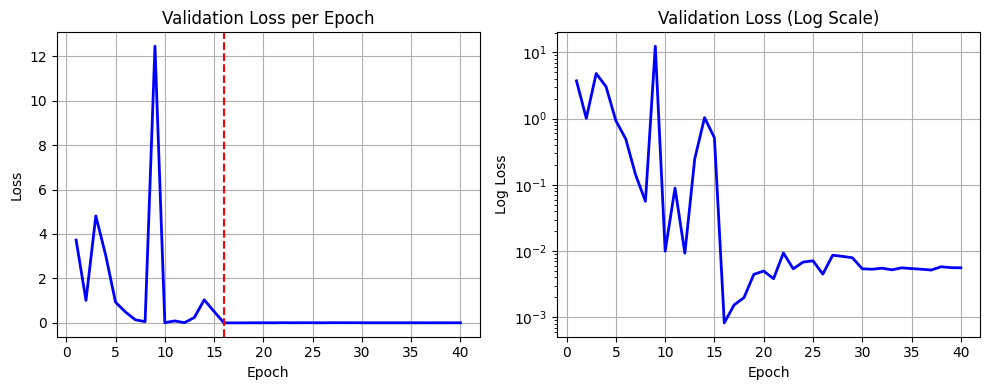


Validation loss per epoch:
Epoch  1: 3.726664
Epoch  2: 1.012907
Epoch  3: 4.813458
Epoch  4: 3.047395
Epoch  5: 0.931898
Epoch  6: 0.494309
Epoch  7: 0.142004
Epoch  8: 0.056496
Epoch  9: 12.448652
Epoch 10: 0.009981
Epoch 11: 0.089747
Epoch 12: 0.009284
Epoch 13: 0.245952
Epoch 14: 1.038742
Epoch 15: 0.513787
Epoch 16: 0.000824
Epoch 17: 0.001538
Epoch 18: 0.001984
Epoch 19: 0.004457
Epoch 20: 0.004998
Epoch 21: 0.003829
Epoch 22: 0.009368
Epoch 23: 0.005399
Epoch 24: 0.006828
Epoch 25: 0.007139
Epoch 26: 0.004495
Epoch 27: 0.008665
Epoch 28: 0.008324
Epoch 29: 0.007937
Epoch 30: 0.005406
Epoch 31: 0.005320
Epoch 32: 0.005523
Epoch 33: 0.005212
Epoch 34: 0.005589
Epoch 35: 0.005441
Epoch 36: 0.005325
Epoch 37: 0.005176
Epoch 38: 0.005804
Epoch 39: 0.005615
Epoch 40: 0.005597


In [ ]:
# Validation Loss Analysis (using existing history object)

val_losses = history.history['val_loss']
best_val_epoch = np.argmin(val_losses) + 1

print(f"Best validation loss: {min(val_losses):.6f} at epoch {best_val_epoch}")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(range(1,41), val_losses, 'b-', linewidth=2)
plt.axvline(best_val_epoch, color='r', linestyle='--')
plt.title('Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(1,41), val_losses, 'b-', linewidth=2)
plt.yscale('log')
plt.title('Validation Loss (Log Scale)')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Val_Loss_Detailed.png', dpi=300)
plt.show()

print("\nValidation loss per epoch:")
for i, loss in enumerate(val_losses, 1):
    print(f"Epoch {i:2d}: {loss:.6f}")


Plateau starts at epoch 2
Best val loss: 0.000824 at epoch 16


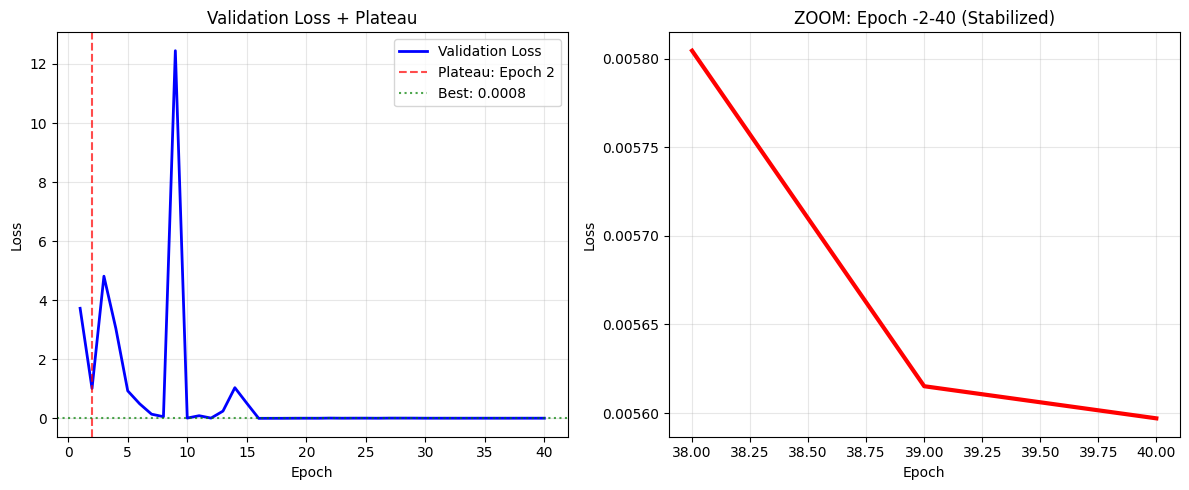


Last 10 epochs validation loss:
Epoch 30: 0.005320
Epoch 31: 0.005523
Epoch 32: 0.005212
Epoch 33: 0.005589
Epoch 34: 0.005441
Epoch 35: 0.005325
Epoch 36: 0.005176
Epoch 37: 0.005804
Epoch 38: 0.005615
Epoch 39: 0.005597


In [ ]:
# ADD THIS TO YOUR CURRENT OPEN NOTEBOOK - Validation Loss Plateau Analysis

import matplotlib.pyplot as plt
import numpy as np

# Get validation loss from history (already exists)
val_losses = history.history['val_loss']
epochs = range(1, len(val_losses) + 1)

# Find where it stabilizes (plateau detection)
diff = np.diff(val_losses)
plateau_start = np.argmax(diff > 0.001) + 1  # First epoch where loss increases >0.001
if plateau_start == 0: plateau_start = len(val_losses)

print(f"Plateau starts at epoch {plateau_start}")
print(f"Best val loss: {min(val_losses):.6f} at epoch {np.argmin(val_losses)+1}")

# Plot with plateau marking
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, val_losses, 'b-', linewidth=2, label='Validation Loss')
plt.axvline(plateau_start, color='red', linestyle='--', alpha=0.7, label=f'Plateau: Epoch {plateau_start}')
plt.axhline(min(val_losses), color='green', linestyle=':', alpha=0.7, label=f'Best: {min(val_losses):.4f}')
plt.title('Validation Loss + Plateau')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs[plateau_start-5:], val_losses[plateau_start-5:], 'r-', linewidth=3)
plt.title(f'ZOOM: Epoch {plateau_start-4}-{len(epochs)} (Stabilized)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Val_Loss_Plateau.png', dpi=300, bbox_inches='tight')
plt.show()

# Print last 10 epochs values
print("\nLast 10 epochs validation loss:")
for i in range(-10, 0):
    print(f"Epoch {len(val_losses)+i}: {val_losses[i]:.6f}")


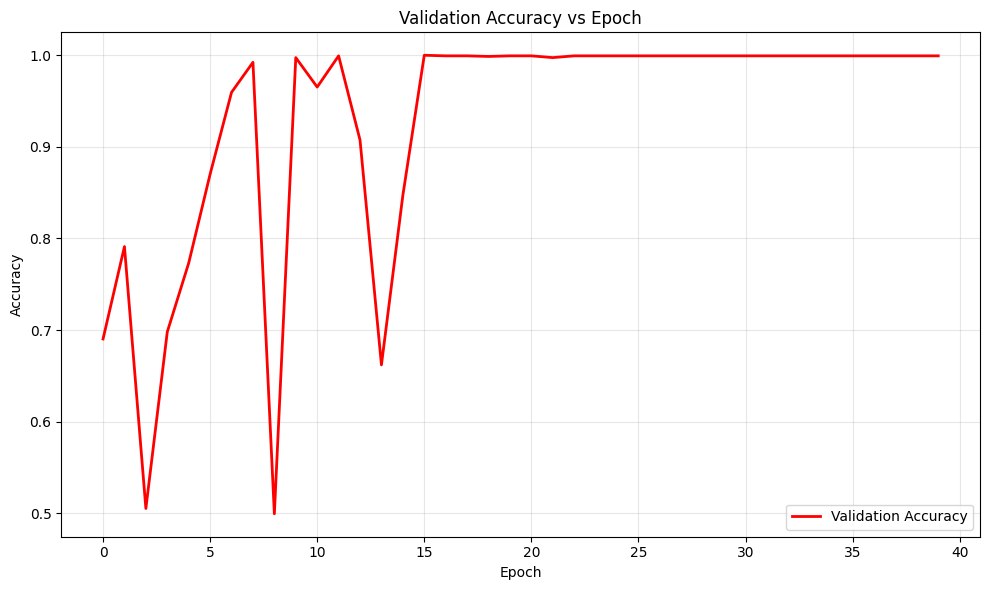

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/val_accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()


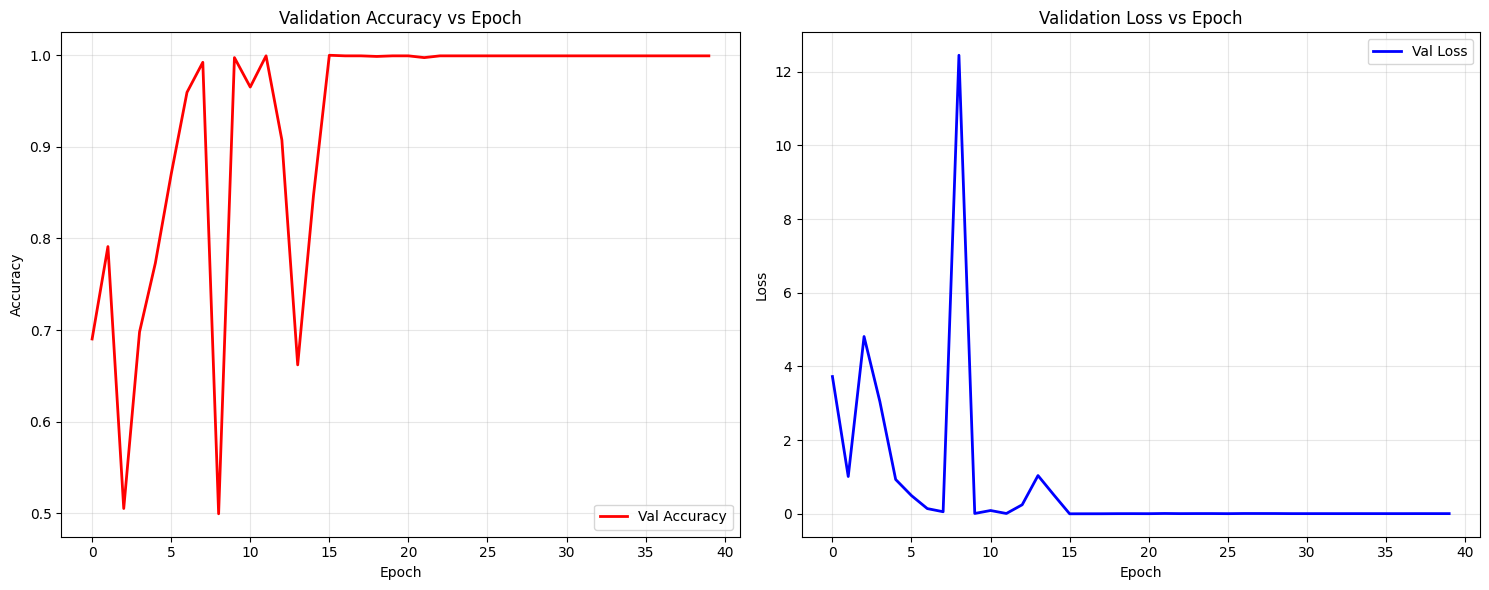

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Validation Accuracy
ax1.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Val Accuracy')
ax1.set_title('Validation Accuracy vs Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Validation Loss
ax2.plot(history.history['val_loss'], 'b-', linewidth=2, label='Val Loss')
ax2.set_title('Validation Loss vs Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/val_accuracy_loss_standard.png', dpi=300, bbox_inches='tight')
plt.show()


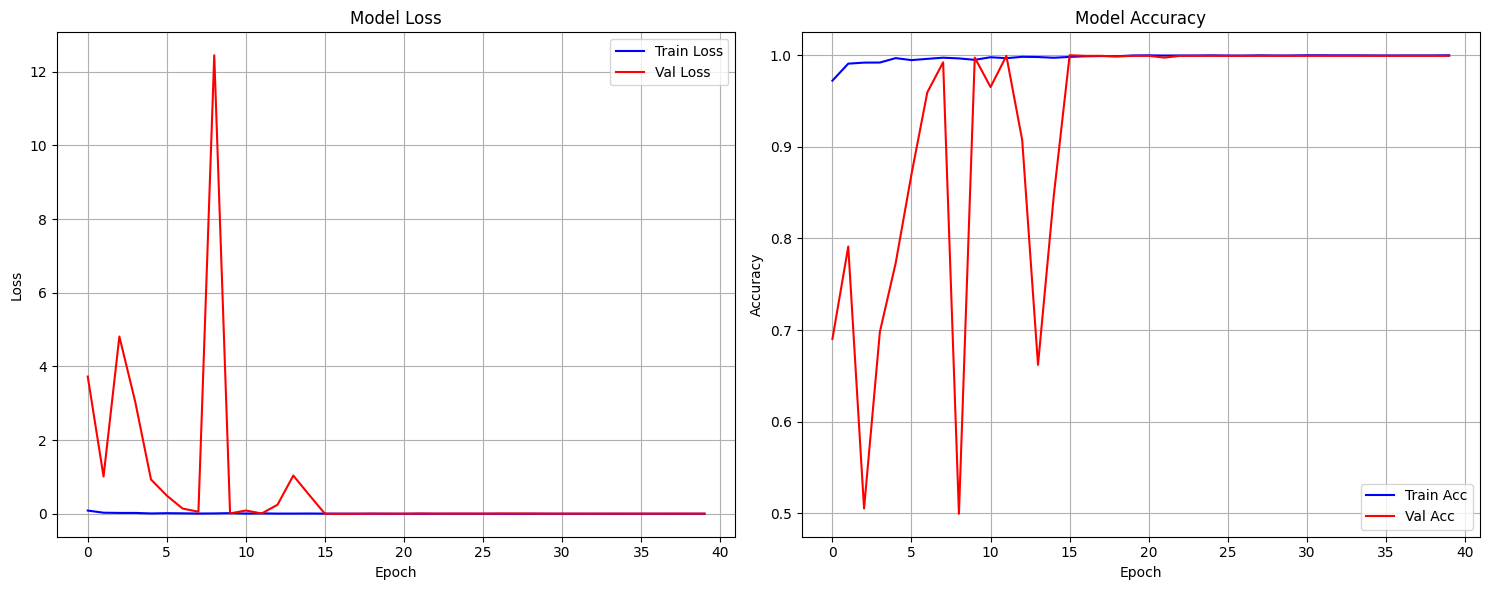

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Loss curves
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='red')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Accuracy curves
ax2.plot(history.history['accuracy'], label='Train Acc', color='blue')
ax2.plot(history.history['val_accuracy'], label='Val Acc', color='red')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
